In [1]:
import pandas as pd
import numpy as np

training_data_pd = pd.read_csv('data/train.csv')

training_data_pd.head()
training_data_pd.info()
training_data_pd.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [2]:
print(training_data_pd['health_condition'].unique())

['unhealthy' 'at-risk' 'fit']


In [3]:
# dataset balance:
total_data_points = training_data_pd.shape[0]
print("Total data points:", total_data_points)

number_of_fit = training_data_pd[training_data_pd['health_condition'] == 'fit'].shape[0]
number_of_unhealthy = training_data_pd[training_data_pd['health_condition'] == 'unhealthy'].shape[0]
number_of_at_risk = training_data_pd[training_data_pd['health_condition'] == 'at-risk'].shape[0]
print("Percentage of fit students:", number_of_fit/total_data_points *100)
print("Percentage of unhealthy students:", number_of_unhealthy/total_data_points *100)
print("Percentage of at risk students:", number_of_at_risk/total_data_points *100)

balance = training_data_pd['health_condition'].value_counts(normalize=True, dropna=False) * 100

print("Cathegorical percentage:")
print(balance)

Total data points: 690088
Percentage of fit students: 5.76781511923117
Percentage of unhealthy students: 8.36473029526669
Percentage of at risk students: 85.86745458550213
Cathegorical percentage:
health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64


In [4]:
# Count missing values in each column
missing_values = training_data_pd.isna().sum()

# Filter and display only columns that have at least one NaN
columns_with_nans = missing_values[missing_values > 0]

if columns_with_nans.empty:
    print("✅ No missing values (NaNs) found in the dataset!")
else:
    print("⚠️ Missing values found:")
    print(columns_with_nans)
    
    # Optional: Show as percentage
    print("\nPercentage of missing data:")
    print((columns_with_nans / len(training_data_pd)) * 100)

⚠️ Missing values found:
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

Percentage of missing data:
sleep_duration             11.012943
heart_rate                  1.135073
bmi                         2.013946
calorie_expenditure         7.658878
step_count                  2.016554
exercise_duration           1.000017
water_intake                6.300211
diet_type                   1.000017
stress_level               12.000064
sleep_quality               8.452690
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
dtype: float64


In [5]:
training_data_pd.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


# Data Analysis

## 1. Target Variable (`health_condition`)
**Class Distribution:**
* `at-risk`: 85.87% (Majority class)
* `unhealthy`: 8.36%
* `fit`: 5.77% (Minority class)

## 2. Evaluation Metric & Strategy
* **Metric:** `Balanced Accuracy`
* **Observation:** The dataset is **highly imbalanced**. Because the competition evaluates submissions using Balanced Accuracy, a naive model that predicts the majority class (`at-risk`) for every student will achieve a very poor score (~33.3%). 
* **Next Steps:** We must force the model to pay attention to the minority classes (`fit` and `unhealthy`). This will require techniques such as **Class Weights**, **Resampling (SMOTE)**, or specific hyperparameter tuning for tree-based models.

In [6]:
for feature in training_data_pd.columns:
    if training_data_pd[feature].dtype == 'object':
        print(f"Feature: {feature}, Unique Values: {training_data_pd[feature].unique()}")

Feature: health_condition, Unique Values: ['unhealthy' 'at-risk' 'fit']
Feature: diet_type, Unique Values: ['veg' 'non-veg' 'balanced' nan]
Feature: stress_level, Unique Values: ['high' 'low' nan 'medium']
Feature: sleep_quality, Unique Values: ['average' 'poor' nan 'good']
Feature: physical_activity_level, Unique Values: ['sedentary' 'moderate' 'active' nan]
Feature: smoking_alcohol, Unique Values: ['yes' 'occasional' nan 'no']
Feature: gender, Unique Values: ['female' 'other' 'male' nan]


In [7]:
# text to numeric conversion

# stress level
training_data_pd['stress_level'] = training_data_pd['stress_level'].map({'low': 0, 'medium': 1, 'high': 2})

# sleep quality
training_data_pd['sleep_quality'] = training_data_pd['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2})

# physical activity level
training_data_pd['physical_activity_level'] = training_data_pd['physical_activity_level'].map({'sedentary': 0, 'moderate': 1, 'active': 2})

# smoking_alcohol
training_data_pd['smoking_alcohol'] = training_data_pd['smoking_alcohol'].map({'no': 0, 'occasional': 1, 'yes': 2})

# diet type
training_data_pd['diet_type'] = training_data_pd['diet_type'].map({'veg': 0, 'non-veg': 1, 'balanced': 2})

# gender
training_data_pd['gender'] = training_data_pd['gender'].map({'male': 0, 'female': 1, 'other': 2})


In [8]:
training_data_pd.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,2.0,1.0,0.0,2.0,1.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1.0,0.0,1.0,1.0,2.0,2.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,2.0,0.0,2.0,2.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,2.0,1.0,2.0,1.0,1.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,NaN,1.0,0.0,NaN,0.0


In [9]:
# use of iterative imputer to fill missing values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

y = training_data_pd['health_condition']
ids = training_data_pd['id']

x_features = training_data_pd.drop(columns=['id', 'health_condition'])

imputer = IterativeImputer(max_iter=20, random_state=42)

# from numpy array to pandas dataframe
x_imputed = imputer.fit_transform(x_features)
x_clean_df = pd.DataFrame(x_imputed, columns=x_features.columns)

training_data_clean = pd.concat([ids, x_clean_df, y], axis=1)

print(training_data_clean.isna().sum())

label_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
training_data_clean['health_condition_num'] = training_data_clean['health_condition'].map(label_mapping)

id                         0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
health_condition           0
dtype: int64


In [10]:
training_data_clean.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition,health_condition_num
0,0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,2.000000,1.0,0.0,2.000000,1.0,unhealthy,1
1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1.0,0.000000,1.0,1.0,2.000000,2.0,at-risk,0
2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,2.000000,0.0,2.0,2.000000,0.0,unhealthy,1
3,3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,2.000000,1.0,2.0,1.000000,1.0,unhealthy,1
4,4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,1.135492,1.0,0.0,1.044717,0.0,at-risk,0


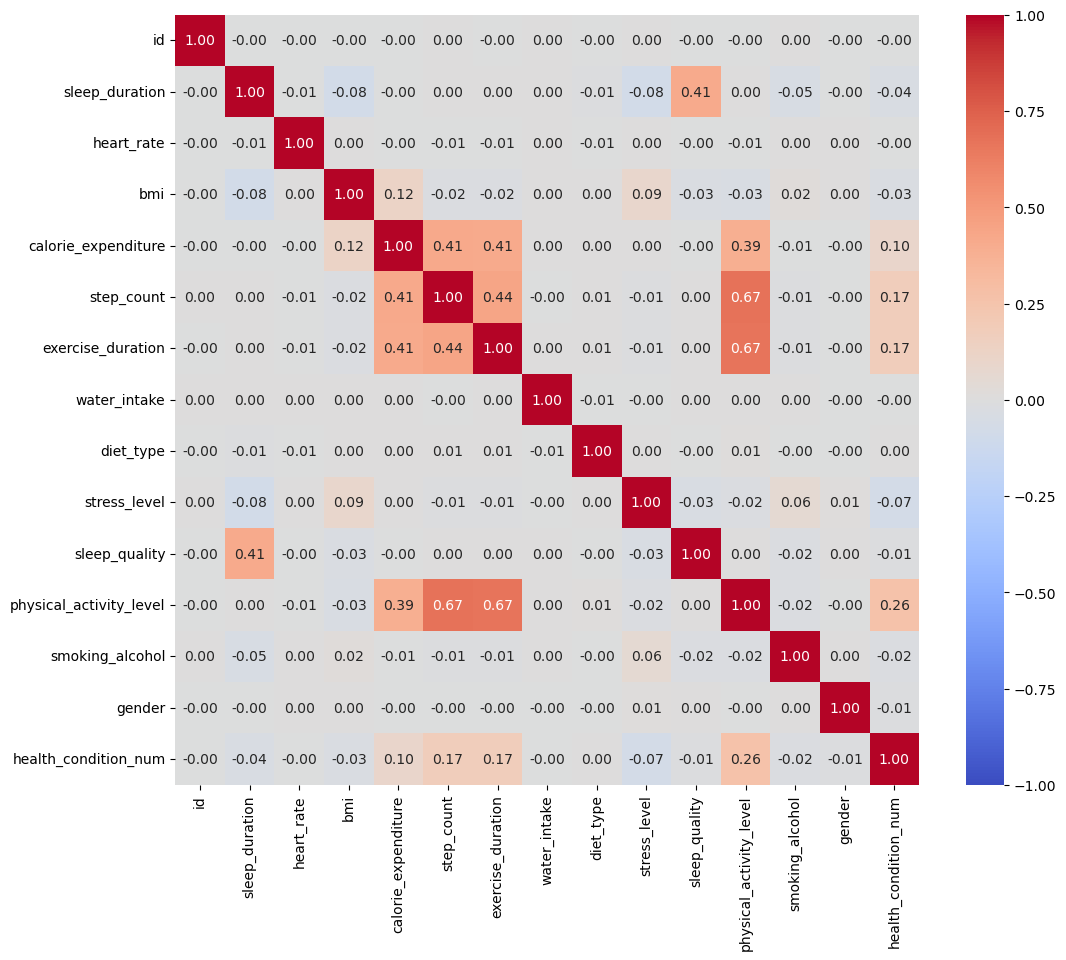

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = training_data_clean.select_dtypes(include=['int64', 'float64'])


# 2. Samotný výpočet korelační matice (Pearsonův koeficient)
correlation_matrix = numeric_data.corr()

# 3. Vizualizace pomocí teplotní mapy
plt.figure(figsize=(12, 10)) # Nastavení velikosti grafu

# Vykreslení heatmapy:
# annot=True zobrazí čísla, cmap nastaví barvy (od modré po červenou), 
# fmt=".2f" zaokrouhlí na 2 desetinná místa
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('')
plt.show()

In [12]:
# preprocess function:
def map_categorical_features(df):
    df_mapped = df.copy()
    
    df_mapped['stress_level'] = df_mapped['stress_level'].map({'low': 0, 'medium': 1, 'high': 2})
    df_mapped['sleep_quality'] = df_mapped['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2})
    df_mapped['physical_activity_level'] = df_mapped['physical_activity_level'].map({'sedentary': 0, 'moderate': 1, 'active': 2})
    df_mapped['smoking_alcohol'] = df_mapped['smoking_alcohol'].map({'no': 0, 'occasional': 1, 'yes': 2})
    
    df_mapped['diet_type'] = df_mapped['diet_type'].map({'veg': 0, 'non-veg': 1, 'balanced': 2})
    df_mapped['gender'] = df_mapped['gender'].map({'male': 0, 'female': 1, 'other': 2})
    
    return df_mapped

def preprocess_train_data(train_df):

    df_mapped = map_categorical_features(train_df)
    
    y_text = df_mapped['health_condition']
    ids = df_mapped['id']
    X_features = df_mapped.drop(columns=['id', 'health_condition'])
    
    imputer = IterativeImputer(max_iter=20, random_state=42)
    X_imputed = imputer.fit_transform(X_features)
    
    X_clean_df = pd.DataFrame(X_imputed, columns=X_features.columns)
    
    train_clean = pd.concat([ids, X_clean_df, y_text], axis=1)
    
    label_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
    train_clean['health_condition_num'] = train_clean['health_condition'].map(label_mapping)
    
    return train_clean, imputer

def preprocess_test_data(test_df, trained_imputer):

    df_mapped = map_categorical_features(test_df)
    
    ids = df_mapped['id']
    X_features = df_mapped.drop(columns=['id'])
    
    X_imputed = trained_imputer.transform(X_features) 
    
    X_clean_df = pd.DataFrame(X_imputed, columns=X_features.columns)
    test_clean = pd.concat([ids, X_clean_df], axis=1)
    
    return test_clean

## XGBoost algorithm
- no need to remove any redundant features, because XGBoost is tree like algorithm

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, make_scorer

training_data_pd = pd.read_csv('data/train.csv')


training_data_clean, learned_imputer = preprocess_train_data(training_data_pd)


x = training_data_clean.drop(columns=['id', 'health_condition', 'health_condition_num'])
y = training_data_clean['health_condition_num']

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # StratifiedKFold ensures that each fold has the same proportion of classes as the original dataset
scores = []
models_in_array = []

print("🚀 Začínám trénink...")
for fold, (train_idx, val_idx) in enumerate(cv.split(x, y)):
    
    X_train, X_val = x.iloc[train_idx], x.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    w_train = sample_weights[train_idx]
    
    xgb_model = XGBClassifier(
        n_estimators=300,      
        max_depth=10,           
        learning_rate=0.1,
        tree_method='hist',    
        random_state=42,
        n_jobs=-1              
    )
    
    xgb_model.fit(X_train, y_train, sample_weight=w_train)
    
    y_pred = xgb_model.predict(X_val)
    score = balanced_accuracy_score(y_val, y_pred)
    scores.append(score)
    
    models_in_array.append(xgb_model)
    
    print(f"Fold {fold + 1} - Balanced Accuracy: {score * 100:.2f} %")

print("-" * 40)
print(f"🏆 Averaged Balanced Accuracy (BASELINE): {np.mean(scores) * 100:.2f} %")

🚀 Začínám trénink...


In [ ]:
import subprocess

print("⚙️ 1. Zpracovávám testovací data...")
test_data_pd = pd.read_csv('data/test.csv')

# Zpracování pomocí naučeného imputeru z kroku 1
test_data_clean = preprocess_test_data(test_data_pd, learned_imputer)

print("\n🔮 2. Spouštím predikci na testovacích datech...")
test_ids = test_data_clean['id']
X_test_final = test_data_clean.drop(columns=['id'])

import time
# Mřížka pravděpodobností
y_preds_proba = np.zeros((len(X_test_final), 3))

# Hlasování uložených modelů
for model in models_in_array:
    y_preds_proba += model.predict_proba(X_test_final)

# Průměrování a finální volba
y_preds_proba /= len(models_in_array)
final_predictions_num = np.argmax(y_preds_proba, axis=1)

print("📝 3. Převádím čísla zpět na texty a ukládám CSV...")
reverse_mapping = {0: 'at-risk', 1: 'unhealthy', 2: 'fit'}
final_labels = [reverse_mapping[num] for num in final_predictions_num]

submission_file = 'submission_xgboost_ensemble.csv'
submission = pd.DataFrame({'id': test_ids, 'health_condition': final_labels})
submission.to_csv(submission_file, index=False)

print(f"✅ Soubor {submission_file} byl úspěšně vygenerován!")

print("\n🚀 4. Odesílám na Kaggle přes API...")
message = "XGBoost Local Ensemble s IterativeImputerem"

# TOTO je ten příkaz, který fyzicky nahraje soubor na Kaggle
submit_result = subprocess.run([
    'kaggle', 'competitions', 'submit', 
    '-c', 'playground-series-s6e7', 
    '-f', submission_file, 
    '-m', message
], capture_output=True, text=True)

print("Odpověď od Kaggle serveru:")
print(submit_result.stdout)
if submit_result.stderr:
    print("Chyba při odesílání:", submit_result.stderr)


# =========================================================
# ČEKÁNÍ A STAŽENÍ VÝSLEDKŮ
# =========================================================
print("\n⏳ Čekám 60 vteřin, než Kaggle vyhodnotí tvůj soubor na serverech...")
time.sleep(60)

print("📊 Stahuji aktuální skóre z Leaderboardu...")
result_score = subprocess.run([
    'kaggle', 'competitions', 'submissions', 
    '-c', 'playground-series-s6e7'
], capture_output=True, text=True)

print("\n🏆 Tvé aktuální výsledky na Kaggle:")
print(result_score.stdout)

⚙️ 1. Zpracovávám testovací data...

🔮 2. Spouštím predikci na testovacích datech...
📝 3. Převádím čísla zpět na texty a ukládám CSV...
✅ Soubor submission_xgboost_ensemble.csv byl úspěšně vygenerován!

🚀 4. Odesílám na Kaggle přes API...

⏳ Čekám 15 vteřin, než Kaggle vyhodnotí tvůj soubor na serverech...
📊 Stahuji aktuální skóre z Leaderboardu...

🏆 Tvé aktuální výsledky na Kaggle:
No submissions found

